In [ ]:
%pip install puremacro


# Continuous Transition Dynamics and MIT Shocks: Non-Linear Distributional Sequence Space

**How do the wealth distribution $\mu_t(k, z)$ and the factor prices $\{r_t, w_t\}$ of an incomplete-markets economy move after an unexpected, temporary productivity shock, and how long does the response outlast the shock itself?**

In a Bewley-Huggett-Aiyagari economy the cross-sectional distribution of wealth is a state variable. When an unexpected aggregate shock hits (an "MIT shock": a zero-probability event that, once it happens, everyone foresees perfectly), the distribution $\mu_0(k, z)$ is predetermined on impact, so aggregate capital cannot jump. Factor markets clear through the prices instead: the real wage and the real interest rate move on impact, and capital adjusts only as households save.

This notebook computes the non-linear transition path of the whole distribution. A backward Endogenous Grid Method (EGM) pass gives the household policies along a price path, a forward pass with the Young (2010) lottery moves the distribution, $\mu_{t+1} = \mathcal{T}_t^* \mu_t$, and a Broyden quasi-Newton iteration on the whole interest-rate path clears the capital market at every date. The calibration is annual ($\beta = 0.96$, $\delta = 0.08$), so one period is one year.

## The method in math — Continuous Transition Dynamics and MIT Shocks

**1. Backward Endogenous Grid Method (EGM).** Given a path of factor prices $\{r_t, w_t\}_{t=0}^{T-1}$ and the consumption policy of the terminal steady state at date $T$, household policies are computed backward from $t = T-1$ to $t = 0$. With CRRA utility $u(c) = \frac{c^{1-\gamma} - 1}{1-\gamma}$, a household with productivity $z_i$ that chooses savings $a'$ satisfies the Euler equation
$$ u'\left(c_t^{\text{endo}}(a', z_i)\right) = \beta (1 + r_{t+1}) \sum_{j=1}^{n_z} P_z(z_i, z_j) \left[c_{t+1}(a', z_j)\right]^{-\gamma}, $$
so the endogenous consumption is obtained by inverting marginal utility, $c_t^{\text{endo}}(a', z_i) = \left(\beta (1 + r_{t+1}) \sum_{j} P_z(z_i, z_j) \left[c_{t+1}(a', z_j)\right]^{-\gamma}\right)^{-1/\gamma}$. From the budget constraint $(1 + r_t) a_t + w_t z_i = c_t + a'$, the beginning-of-period assets that lead to the choice $a'$ are:
$$ a_t^{\text{endo}}(a', z_i) = \frac{c_t^{\text{endo}}(a', z_i) + a' - w_t z_i}{1 + r_t}. $$
Linearly interpolating the pairs $(a_t^{\text{endo}}, a')$ onto the fixed asset grid $\mathcal{K} = \{k_1, \dots, k_{N_k}\}$ and imposing the borrowing constraint $a' \ge 0$ gives the policies $a'_t(k, z_i) = \max\left\{0, \text{interp}\left(k; a_t^{\text{endo}}(\cdot, z_i), a'\right)\right\}$ and $c_t(k, z_i) = (1 + r_t) k + w_t z_i - a'_t(k, z_i)$.

**2. Forward density evolution (Young 2010 lottery).** Starting from the stationary distribution $\mu_0(k, z)$, the density moves forward with the policy sequence $\{a'_t\}_{t=0}^{T-1}$. A savings choice $a' = a'_t(k_i, z_j)$ in the grid bracket $[k_m, k_{m+1}]$ is split between the two nodes so that the expected value of $a'$ is preserved:
$$ w_{\text{lo}}(a') = \frac{k_{m+1} - a'}{k_{m+1} - k_m}, \qquad w_{\text{hi}}(a') = 1 - w_{\text{lo}}(a'). $$
The forward operator $\mathcal{T}_t^*$ scatters mass along the asset grid and then applies the productivity transition:
$$ \mu_{t+1}(k_m, z_l) = \sum_{j=1}^{n_z} P_z(z_j, z_l) \sum_{i=1}^{N_k} \mu_t(k_i, z_j) \left[ w_{\text{lo}}\left(a'_t(k_i, z_j)\right) \mathbf{1}_{\{m = j_{\text{lo}}\}} + w_{\text{hi}}\left(a'_t(k_i, z_j)\right) \mathbf{1}_{\{m = j_{\text{hi}}\}} \right]. $$
The weights sum to one, so the operator conserves total mass up to rounding error; the run below prints the largest deviation of $\sum_{k, z} \mu_t(k, z)$ from one.

**3. Market clearing in sequence space.** Aggregate capital supply is $K_t^s(\mathbf{r}) = \sum_{i=1}^{N_k} \sum_{j=1}^{n_z} k_i \, \mu_t(k_i, z_j)$. A competitive firm with technology $Y_t = Z_t (K_t^d)^\alpha L^{1-\alpha}$ and depreciation $\delta$ sets $r_t = \alpha Z_t (K_t^d / L)^{\alpha - 1} - \delta$ and $w_t = (1 - \alpha) Z_t (K_t^d / L)^\alpha$, so capital demand is
$$ K_t^d(r_t; Z_t) = L \left( \frac{r_t + \delta}{\alpha Z_t} \right)^{\frac{1}{\alpha - 1}}. $$
Equilibrium requires clearing at every date $t = 0, \dots, T-1$:
$$ H_t(\mathbf{r}) \equiv K_t^s(\mathbf{r}) - K_t^d(r_t; Z_t) = 0, \qquad \mathbf{H}(\mathbf{r}) = \mathbf{0} \in \mathbb{R}^T. $$
The terminal condition at date $T$ is the initial steady state for every transitory shock ($\rho < 1$), and the shock is set to zero from $T$ on. `continuous_mit_shock` records the shock left at $T-1$, $s\rho^{T-1}$, in `metadata["mit_shock"]` and warns when its share of the impact, $\rho^{T-1}$, exceeds `truncation_tol` $= 10^{-3}$; at $T = 40$ that is any $\rho$ above $0.838$ (printed in Experiment 2). A permanent shock must be asked for with `persistence=1.0`, which solves a terminal steady state at $Z = 1 + s$. Through release 4.3.0 a transitory shock whose $Z_{T-1}$ differed from one by more than about $10^{-5}$ was silently solved as a permanent one at $Z_{T-1}$; at $T = 40$ and $s = 0.05$ that happened for every $\rho$ above $0.806$.

**4. Broyden quasi-Newton.** The system $\mathbf{H}(\mathbf{r}) = \mathbf{0}$ is solved with Broyden's method, which updates an approximate inverse Jacobian by rank-one (Sherman-Morrison) corrections:
$$ B_{k+1} = B_k + \frac{(\Delta \mathbf{r}_k - B_k \Delta \mathbf{H}_k)(\Delta \mathbf{r}_k^\top B_k)}{\Delta \mathbf{r}_k^\top B_k \Delta \mathbf{H}_k}, \qquad \mathbf{r}_{k+1} = \mathbf{r}_k - \theta \, B_k \mathbf{H}(\mathbf{r}_k), $$
where $\theta \in (0, 1]$ is the step accepted by a backtracking line search and $B_0 = \text{diag}\left( \frac{1 - \alpha}{K_t^d} (r_t + \delta) \right)$ inverts the diagonal of the firm's demand derivative. The `damping` keyword does not enter this iteration. Broyden uses it only for a fallback step, taken when the line search fails, and that never happens in this notebook. It is the relaxation weight $\omega$ of the shooting solver of Experiment 4, $\mathbf{r}_{k+1} = (1 - \omega)\,\mathbf{r}_k + \omega\,\mathbf{r}_k^{\text{implied}}$.

**5. A closed form for the impact response.** Because $K_0 = K^*$, the firm's conditions give the date-0 prices directly. With $Z_0 = 1 + s$,
$$ r_0 - r^* = s\,(r^* + \delta), \qquad \frac{w_0}{w^*} - 1 = s. $$
This is derived by hand from the firm's first-order conditions and does not use the solver, so it is an independent check on the date-0 prices it returns.

## Intuition

**Intuition.** In a representative-agent model, a productivity shock moves capital along a saddle path. With uninsurable earnings risk, the wealth distribution adds inertia: capital is the sum of many households' savings, and those savings take time to accumulate.

When a $+5\%$ TFP shock hits unexpectedly, the marginal products of capital and labour rise at once. Capital is predetermined at $t = 0$, so the interest rate and the wage absorb the whole impact, exactly as the closed form above says. The higher return and the higher wage both raise saving. Households near the borrowing constraint, whose income is mostly labour income, can rebuild their buffer stocks, and wealthier households earn more on their capital.

Capital therefore rises for several years, even as the shock decays. As capital accumulates, its marginal product falls, and the interest rate drops below its steady-state value while capital is still above $K^*$. Capital keeps rising as long as net saving is positive, so its peak comes after the interest rate has already turned. The wealth distribution then drifts back toward the stationary one.

Finding the equilibrium means finding the whole path $\mathbf{r} = \{r_t\}_{t=0}^{T-1}$ at which household saving equals firm demand at every date. Broyden's method treats that path as one vector and updates an approximate Jacobian, which typically converges superlinearly. Damped fixed-point iteration ("shooting") on the same system also converges here, only in more iterations.

In [1]:
# Preamble: import numerical libraries, plotting style, and continuous solvers
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.vfi import (
    solve_aiyagari_continuous,
    continuous_mit_shock,
    ContinuousStationaryDistribution,
)

# Nothing below is random; the seed is set only by convention.
rng = np.random.default_rng(42)

# Calibration (annual: one period is one year)
beta = 0.96      # household discount factor
gamma = 2.0      # coefficient of relative risk aversion (CRRA)
alpha = 0.36     # capital share (Cobb-Douglas)
delta = 0.08     # depreciation rate per year
rho_z = 0.90     # persistence of idiosyncratic labour productivity
sigma_z = 0.20   # standard deviation of productivity innovations
N_k = 150        # asset grid nodes
n_z = 5          # productivity states

print(f"Calibration: beta={beta}, gamma={gamma}, alpha={alpha}, delta={delta}, "
      f"rho_z={rho_z}, sigma_z={sigma_z}, N_k={N_k}, n_z={n_z}")

Calibration: beta=0.96, gamma=2.0, alpha=0.36, delta=0.08, rho_z=0.9, sigma_z=0.2, N_k=150, n_z=5


In [2]:
# --- Experiment 1: Baseline stationary incomplete-markets equilibrium ---
# The solver's controls are written out explicitly: the EGM stops when the consumption
# policy moves by less than egm_tol (or after egm_max_iter steps, which it reports),
# Brent's method on r stops at xtol, and the equilibrium counts as converged only if
# |K^s - K^d| < tol_ge at r* and the stationary distribution converged too.
ss_base = solve_aiyagari_continuous(
    beta=beta,
    gamma=gamma,
    alpha=alpha,
    delta=delta,
    rho_z=rho_z,
    sigma_z=sigma_z,
    N_k=N_k,
    n_z=n_z,
    max_evals=60,
    egm_tol=1e-8,
    egm_max_iter=10_000,
    xtol=1e-8,
    tol_ge=1e-4,
)
meta = ss_base.metadata

# Baseline wealth inequality statistics
K_hist = ss_base.distribution.asset_grid
gini_base = ss_base.distribution.gini()
p_lorenz, L_base = ss_base.distribution.lorenz(100)
p50_base = ss_base.distribution.percentile(50.0)
p90_base = ss_base.distribution.percentile(90.0)
Y_base = float((ss_base.K ** alpha) * (ss_base.L ** (1.0 - alpha)))

print("Baseline stationary equilibrium:")
print(f"  Interest rate r*          = {ss_base.r:.6f} ({ss_base.r * 100:.3f}%), 1/beta - 1 = {(1 / beta - 1) * 100:.3f}%")
print(f"  Real wage w*              = {ss_base.w:.6f}")
print(f"  Capital K*                = {ss_base.K:.4f}")
print(f"  Output Y*                 = {Y_base:.4f}")
print(f"  Capital-output ratio K/Y  = {ss_base.K / Y_base:.3f}")
print(f"  Wealth Gini G*            = {gini_base:.4f}")
print(f"  Median wealth (P50)       = {p50_base:.3f}")
print(f"  90th percentile (P90)     = {p90_base:.3f}")
print("Convergence diagnostics:")
print(f"  converged                 = {ss_base.converged}")
print(f"  EGM at r*                 : converged={meta['egm_converged']}, {meta['egm_iterations']} iterations, "
      f"step {meta['egm_residual']:.1e} (egm_tol {meta['egm_tol']:.0e}); cap hits in the search: {meta['egm_cap_hits']}")
print(f"  Stationary distribution   : converged={meta['dist_converged']}, mass error {ss_base.distribution.mass_error:.1e}")
print(f"  Market clearing |K^s-K^d| = {ss_base.capital_market_clearing_error:.1e} (tol_ge {meta['tol_ge']:.0e}) "
      f"after {ss_base.n_evals} evaluations of r")

# Each flag is a real check since the 30 September fixes: through 4.3.0 `converged` was always True
# and the household EGM stopped silently at 500 iterations.
assert ss_base.converged and meta["egm_converged"] and meta["dist_converged"] and not meta["nonconvergence_reasons"]
assert ss_base.capital_market_clearing_error < meta["tol_ge"]
assert ss_base.distribution.mass_error < 1e-12
assert 0.0 < ss_base.r < 1.0 / beta - 1.0, "precautionary saving must push r* below the rate of time preference"
assert 0.40 < gini_base < 0.65, "sanity range for this calibration, not an empirical target"

Baseline stationary equilibrium:
  Interest rate r*          = 0.019762 (1.976%), 1/beta - 1 = 4.167%
  Real wage w*              = 1.317296
  Capital K*                = 8.7924
  Output Y*                 = 2.4365
  Capital-output ratio K/Y  = 3.609
  Wealth Gini G*            = 0.5269
  Median wealth (P50)       = 5.800
  90th percentile (P90)     = 22.702
Convergence diagnostics:
  converged                 = True
  EGM at r*                 : converged=True, 308 iterations, step 9.7e-09 (egm_tol 1e-08); cap hits in the search: 0
  Stationary distribution   : converged=True, mass error 0.0e+00
  Market clearing |K^s-K^d| = 8.0e-07 (tol_ge 1e-04) after 10 evaluations of r


In [3]:
# --- Experiment 2: Non-linear transition after an unexpected TFP shock ---
# A 40-year transition after a +5% TFP shock that decays at rate 0.8 per year.
# damping keeps its default: Broyden uses it only if the line search fails (math, section 4).
horizon = 40
shock_size = 0.05
persistence = 0.80

trans_res = continuous_mit_shock(
    ss_base,
    shock_type="tfp",
    shock_size=shock_size,
    persistence=persistence,
    horizon=horizon,
    solver="broyden",
    tol=1e-4,
)
mit = trans_res.metadata["mit_shock"]

# Headline transition metrics
impact_r = trans_res.r_path[0]
impact_w = trans_res.w_path[0]
impact_K_s = trans_res.K_s_path[0]
peak_K_idx = int(np.argmax(trans_res.K_s_path))
peak_K = trans_res.K_s_path[peak_K_idx]
cross_idx = int(np.argmax(trans_res.r_path < ss_base.r))  # first year with r_t below r*
r_jump_bps = (impact_r - ss_base.r) * 1e4
w_jump_pct = (impact_w / ss_base.w - 1.0) * 100.0

# Independent check: the closed form of section 5 of the math
pred_r_jump_bps = shock_size * (ss_base.r + delta) * 1e4
pred_w_jump_pct = shock_size * 100.0

print(f"Transition: {horizon} years, TFP shock {shock_size * 100:+.1f}% with persistence {persistence}")
print(f"  Broyden iterations                 = {trans_res.iterations}; converged = {trans_res.converged} "
      f"(relaxation {trans_res.metadata['relaxation_converged']})")
print(f"  Max market-clearing residual       = {trans_res.max_residual:.2e} (tol 1e-04)")
print(f"  Max mass conservation error        = {trans_res.mass_conservation_error:.1e}")
print(f"  Terminal condition                 = {mit['terminal_condition']}")
print(f"  Shock left at T-1                  = {mit['shock_at_last_date']:.1e} ({mit['remaining_share'] * 100:.3f}% of the impact; "
      f"truncation_tol {mit['truncation_tol'] * 100:.1f}%, truncated = {mit['truncated']})")
print(f"  Warns for persistence above        = {mit['truncation_tol'] ** (1 / (horizon - 1)):.3f} (rho^(T-1) > truncation_tol at T = {horizon})")
print(f"  |K_0^s - K*|                     = {abs(impact_K_s - ss_base.K):.1e}")
print(f"  Impact interest rate r_0           = {impact_r * 100:.3f}% (jump {r_jump_bps:+.2f} bps; closed form {pred_r_jump_bps:+.2f} bps)")
print(f"  Impact real wage w_0               = {impact_w:.4f} (jump {w_jump_pct:+.4f}%; closed form {pred_w_jump_pct:+.4f}%)")
print(f"  First year with r_t < r*           = {cross_idx}")
print(f"  Peak capital K_peak                = {peak_K:.4f} in year {peak_K_idx} (TFP shock left: {shock_size * persistence ** peak_K_idx * 100:.2f}%)")
print(f"  Capital in the last year, t = {horizon - 1}   = {trans_res.K_s_path[-1]:.4f} (K* = {ss_base.K:.4f})")

assert trans_res.converged and trans_res.max_residual < 1e-4
assert mit["terminal_condition"] == "initial_steady_state" and not mit["truncated"]
assert trans_res.mass_conservation_error < 1e-12
assert abs(impact_K_s - ss_base.K) < 1e-10, "capital is predetermined at t = 0"
assert abs(r_jump_bps - pred_r_jump_bps) < 0.1, "impact rate must match the closed form"
assert abs(w_jump_pct - pred_w_jump_pct) < 1e-3, "impact wage must match the closed form"
assert 0 < cross_idx < peak_K_idx, "capital keeps rising after r_t falls below r*"
assert np.isclose(trans_res.K_s_path[-1], ss_base.K, atol=0.05), "capital must be back near K* by the last year"

Transition: 40 years, TFP shock +5.0% with persistence 0.8
  Broyden iterations                 = 5; converged = True (relaxation True)
  Max market-clearing residual       = 2.67e-05 (tol 1e-04)
  Max mass conservation error        = 4.4e-16
  Terminal condition                 = initial_steady_state
  Shock left at T-1                  = 8.3e-06 (0.017% of the impact; truncation_tol 0.1%, truncated = False)
  Warns for persistence above        = 0.838 (rho^(T-1) > truncation_tol at T = 40)
  |K_0^s - K*|                     = 1.8e-15
  Impact interest rate r_0           = 2.475% (jump +49.88 bps; closed form +49.88 bps)
  Impact real wage w_0               = 1.3832 (jump +5.0000%; closed form +5.0000%)
  First year with r_t < r*           = 5
  Peak capital K_peak                = 9.0388 in year 7 (TFP shock left: 1.05%)
  Capital in the last year, t = 39   = 8.8324 (K* = 8.7924)


Wealth inequality along the transition:
  Gini in year 0        = 0.5269
  Minimum Gini (year 7) = 0.5212 (change -0.0057)
  Gini in year 40       = 0.5251
  Share at k = 0        : 0.0707 in year 0, minimum 0.0679 in year 6
  Change in mass by year 7: largest loss -0.28 pp at k = 0.00, largest gain +0.29 pp at k = 2.62


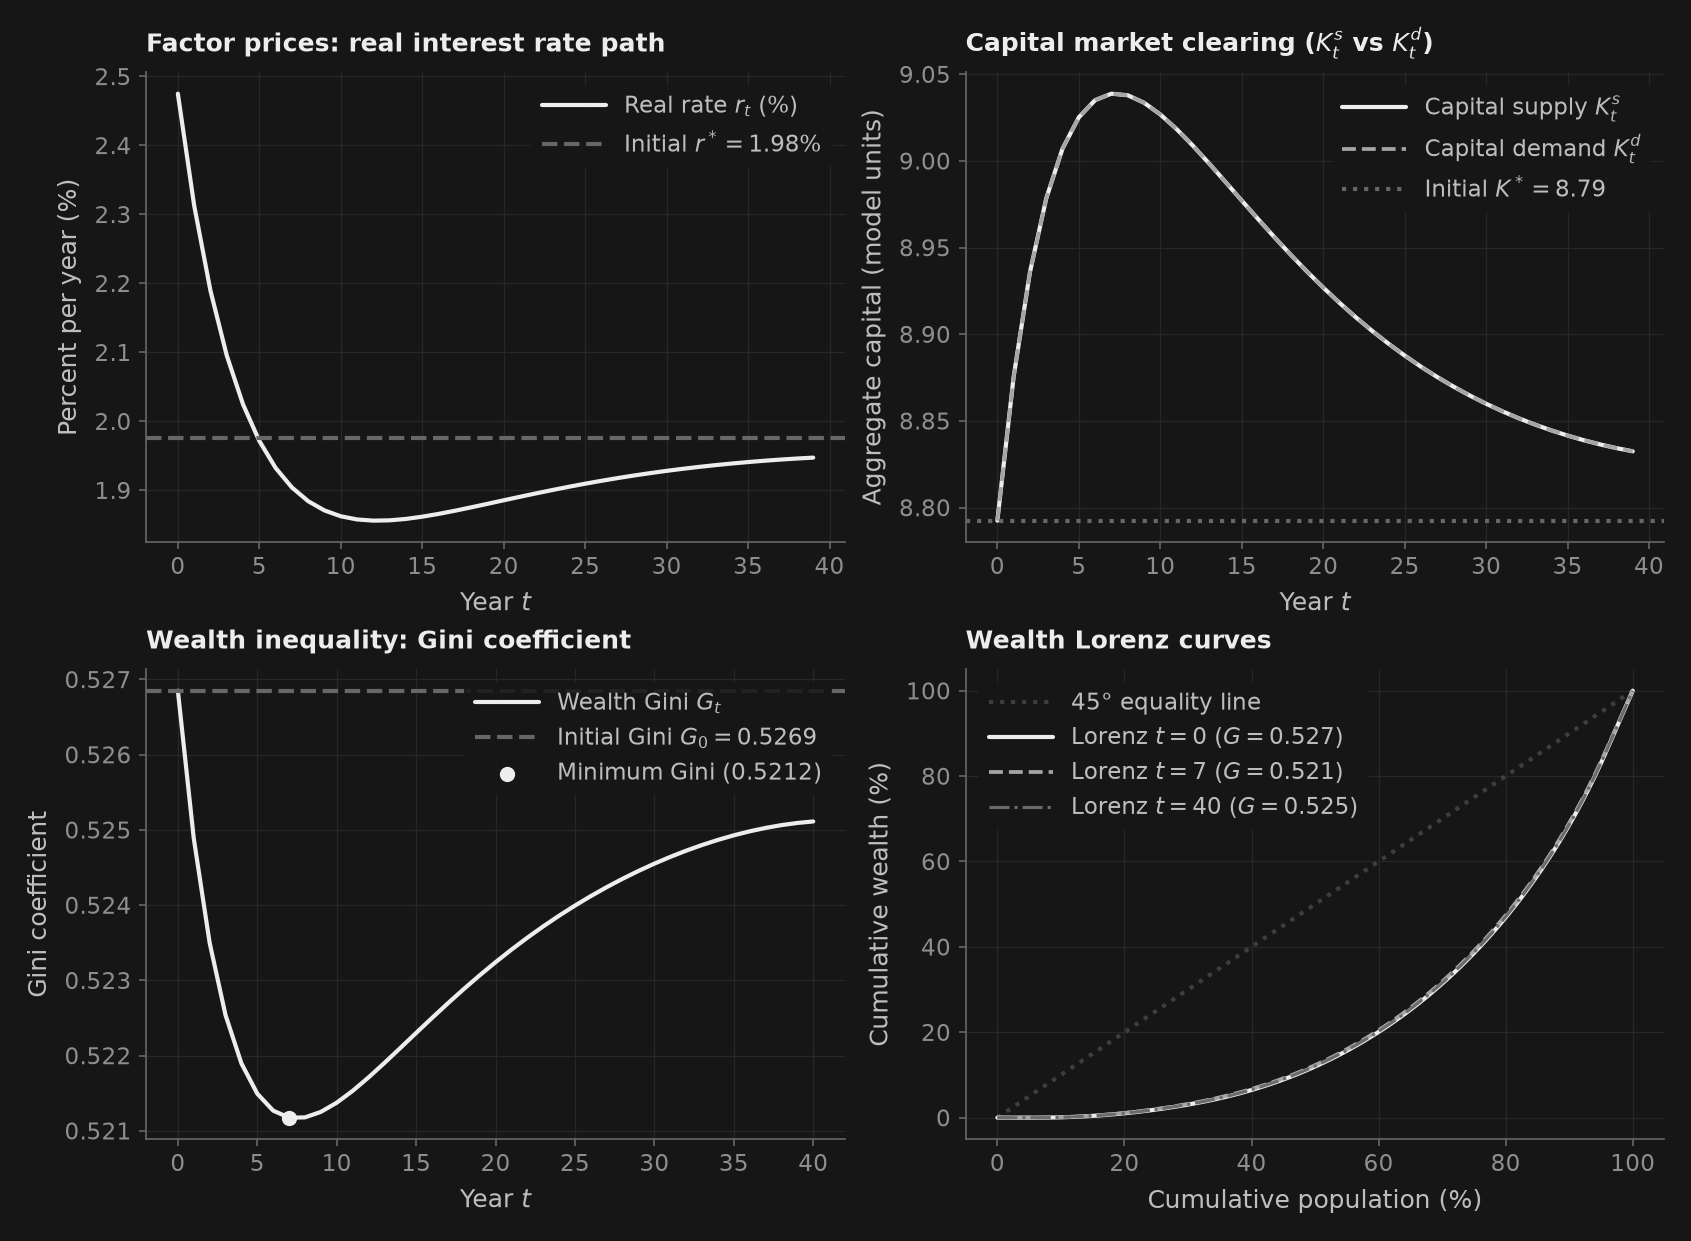

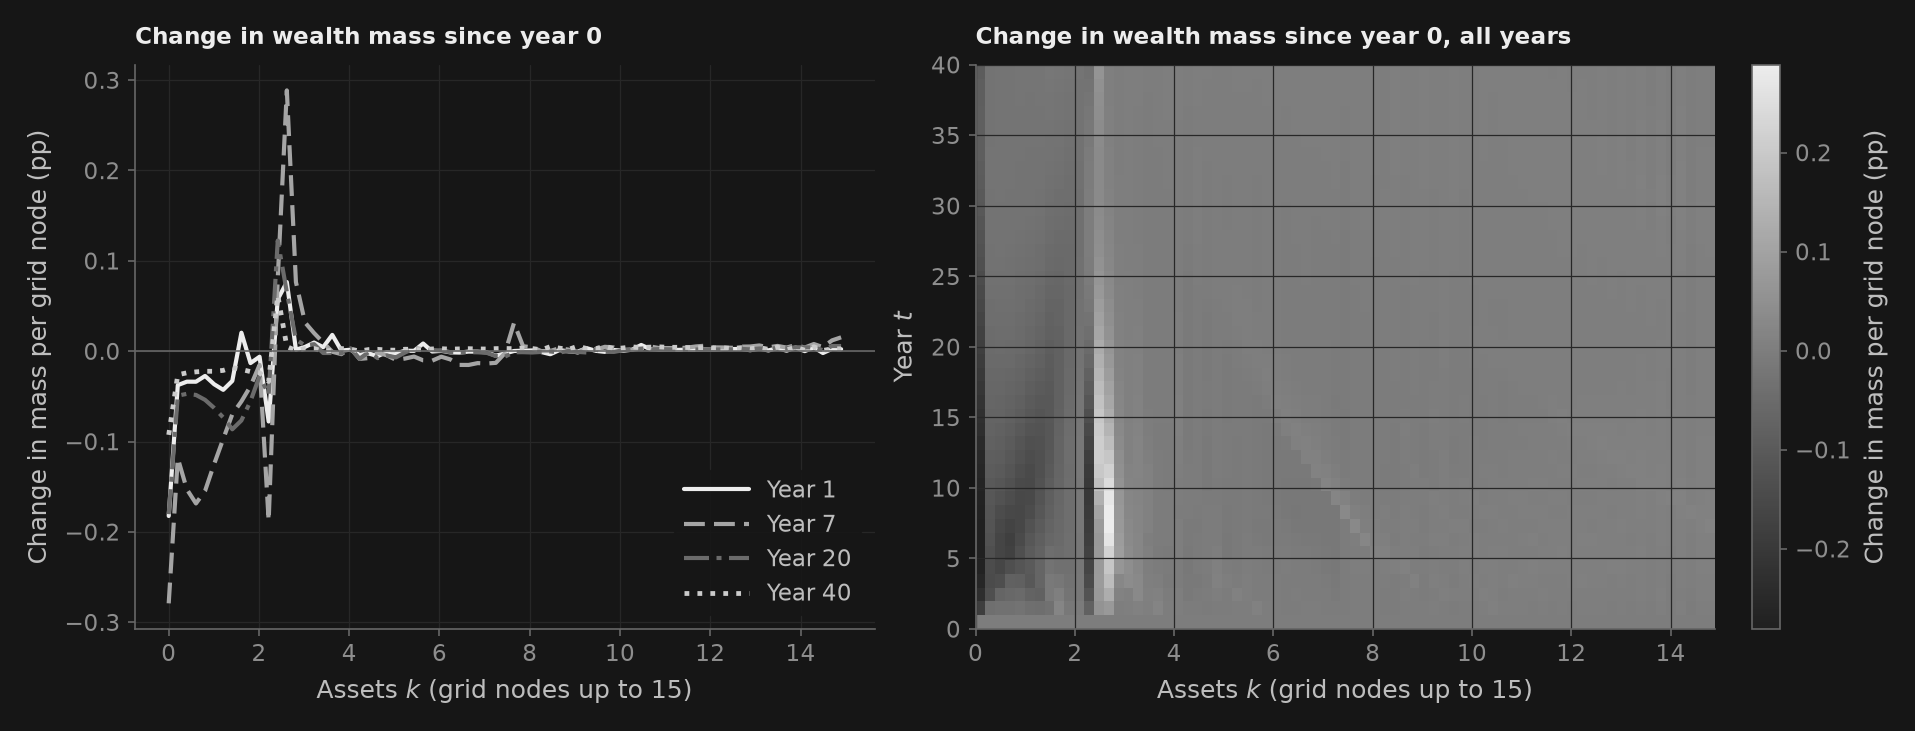

In [4]:
# --- Experiment 3: Wealth inequality along the transition ---
ginis = np.array([
    ContinuousStationaryDistribution(pdf=d, asset_grid=K_hist).gini()
    for d in trans_res.distributions
])
time_grid = np.arange(horizon + 1)
min_gini_idx = int(np.argmin(ginis))
min_gini = ginis[min_gini_idx]
# Share of households at the borrowing constraint k = 0 (first grid node)
at_constraint = np.array([d[0].sum() for d in trans_res.distributions])
# Change since year 0 in the mass of each asset grid node (summed over productivity)
density_mat = np.array([np.sum(d, axis=1) if d.ndim == 2 else d for d in trans_res.distributions])
d_mass = density_mat - density_mat[0]

dist_peak = ContinuousStationaryDistribution(pdf=trans_res.distributions[peak_K_idx], asset_grid=K_hist)
dist_term = ContinuousStationaryDistribution(pdf=trans_res.distributions[-1], asset_grid=K_hist)
_, L_peak = dist_peak.lorenz(100)
_, L_term = dist_term.lorenz(100)

print("Wealth inequality along the transition:")
print(f"  Gini in year 0        = {ginis[0]:.4f}")
print(f"  Minimum Gini (year {min_gini_idx}) = {min_gini:.4f} (change {min_gini - ginis[0]:+.4f})")
print(f"  Gini in year {horizon}       = {ginis[-1]:.4f}")
print(f"  Share at k = 0        : {at_constraint[0]:.4f} in year 0, minimum {at_constraint.min():.4f} in year {int(np.argmin(at_constraint))}")
print(f"  Change in mass by year {peak_K_idx}: largest loss {d_mass[peak_K_idx].min() * 100:+.2f} pp at k = "
      f"{K_hist[np.argmin(d_mass[peak_K_idx])]:.2f}, largest gain {d_mass[peak_K_idx].max() * 100:+.2f} pp at k = "
      f"{K_hist[np.argmax(d_mass[peak_K_idx])]:.2f}")

assert len(trans_res.distributions) == horizon + 1
assert min_gini < ginis[0], "wealth inequality must compress during the expansion"
assert np.isclose(ginis[-1], ginis[0], atol=0.01), "the Gini must return close to its initial level"

# Figure 1: factor prices, market clearing, Gini path and Lorenz curves
fig1, axes1 = _nbstyle.figura(2, 2, figsize=(11, 8))
t_years = np.arange(horizon)

ax1 = axes1[0, 0]
ax1.plot(t_years, trans_res.r_path * 100, label="Real rate $r_t$ (%)", lw=2, color=_nbstyle.S1["color"])
ax1.axhline(ss_base.r * 100, ls="--", color=_nbstyle.SPINE, label=f"Initial $r^*={ss_base.r * 100:.2f}\\%$")
ax1.set_title("Factor prices: real interest rate path")
ax1.set_xlabel("Year $t$")
ax1.set_ylabel("Percent per year (%)")
ax1.legend(loc="upper right")

ax2 = axes1[0, 1]
ax2.plot(t_years, trans_res.K_s_path, label="Capital supply $K_t^s$", lw=2, color=_nbstyle.S1["color"])
ax2.plot(t_years, trans_res.K_d_path, label="Capital demand $K_t^d$", ls="--", lw=1.8, color=_nbstyle.S2["color"])
ax2.axhline(ss_base.K, ls=":", color=_nbstyle.SPINE, label=f"Initial $K^*={ss_base.K:.2f}$")
ax2.set_title("Capital market clearing ($K_t^s$ vs $K_t^d$)")
ax2.set_xlabel("Year $t$")
ax2.set_ylabel("Aggregate capital (model units)")
ax2.legend(loc="upper right")

ax3 = axes1[1, 0]
ax3.plot(time_grid, ginis, label="Wealth Gini $G_t$", lw=2, color=_nbstyle.S1["color"])
ax3.axhline(ginis[0], ls="--", color=_nbstyle.SPINE, label=f"Initial Gini $G_0={ginis[0]:.4f}$")
ax3.scatter([min_gini_idx], [min_gini], color=_nbstyle.S1["color"], s=40, zorder=5, label=f"Minimum Gini ({min_gini:.4f})")
ax3.set_title("Wealth inequality: Gini coefficient")
ax3.set_xlabel("Year $t$")
ax3.set_ylabel("Gini coefficient")
ax3.legend(loc="upper right")

ax4 = axes1[1, 1]
ax4.plot(p_lorenz * 100, p_lorenz * 100, linestyle=":", color=_nbstyle.SPINE, label="45° equality line", alpha=0.5)
ax4.plot(p_lorenz * 100, L_base * 100, label=f"Lorenz $t=0$ ($G={ginis[0]:.3f}$)", lw=2, color=_nbstyle.S1["color"])
ax4.plot(p_lorenz * 100, L_peak * 100, label=f"Lorenz $t={peak_K_idx}$ ($G={ginis[peak_K_idx]:.3f}$)", lw=1.8, ls="--", color=_nbstyle.S2["color"])
ax4.plot(p_lorenz * 100, L_term * 100, label=f"Lorenz $t={horizon}$ ($G={ginis[-1]:.3f}$)", lw=1.5, ls="-.", color=_nbstyle.S3["color"])
ax4.set_title("Wealth Lorenz curves")
ax4.set_xlabel("Cumulative population (%)")
ax4.set_ylabel("Cumulative wealth (%)")
ax4.legend(loc="upper left")

# Figure 2: how the wealth distribution moves. The level is dominated by the mass at k = 0,
# so plot the change since year 0 in the mass of each asset grid node.
k_mask = K_hist <= 15.0
k_sub = K_hist[k_mask]

fig2, (ax_lines, ax_heat) = _nbstyle.figura(1, 2, figsize=(12.5, 4.6))
line_styles = [_nbstyle.S1, _nbstyle.S2, _nbstyle.S3, _nbstyle.S4]
for style, t_show in zip(line_styles, sorted({1, peak_K_idx, 20, horizon})):
    ax_lines.plot(k_sub, d_mass[t_show, k_mask] * 100, **style, label=f"Year {t_show}")
ax_lines.axhline(0, color=_nbstyle.SPINE, lw=0.8)
ax_lines.set_title("Change in wealth mass since year 0", fontsize=11)
ax_lines.set_xlabel("Assets $k$ (grid nodes up to 15)")
ax_lines.set_ylabel("Change in mass per grid node (pp)")
ax_lines.legend(loc="lower right")

im = ax_heat.imshow(d_mass[:, k_mask] * 100, aspect="auto", origin="lower",
                    extent=[k_sub[0], k_sub[-1], 0, horizon], cmap=_nbstyle.CMAP_SEQ)
cbar = fig2.colorbar(im, ax=ax_heat)
cbar.set_label("Change in mass per grid node (pp)")
ax_heat.set_title("Change in wealth mass since year 0, all years", fontsize=11)
ax_heat.set_xlabel("Assets $k$ (grid nodes up to 15)")
ax_heat.set_ylabel("Year $t$")

In [5]:
# --- Experiment 4: Broyden quasi-Newton against damped shooting ---
# Both solve the same system H(r) = 0, so their paths must agree to the tolerance.
# This is an internal consistency check: both routes run through puremacro's code.
shoot_res = continuous_mit_shock(
    ss_base,
    shock_type="tfp",
    shock_size=shock_size,
    persistence=persistence,
    horizon=horizon,
    solver="shooting",
    damping=0.5,
    tol=1e-4,
    max_iter=30,
)
gap_r_bps = np.max(np.abs(shoot_res.r_path - trans_res.r_path)) * 1e4
gap_K = np.max(np.abs(shoot_res.K_s_path - trans_res.K_s_path))

print("Algorithm comparison (same system, same tolerance):")
print(f"  Broyden quasi-Newton : {trans_res.iterations:2d} iterations, max residual {trans_res.max_residual:.2e}")
print(f"  Damped shooting      : {shoot_res.iterations:2d} iterations, max residual {shoot_res.max_residual:.2e}")
print(f"  Largest gap between the two paths: r {gap_r_bps:.1e} bps, K {gap_K:.1e}")

assert trans_res.converged and shoot_res.converged
assert gap_K < 1e-4, "two solvers of the same system must agree to the tolerance"

Algorithm comparison (same system, same tolerance):
  Broyden quasi-Newton :  5 iterations, max residual 2.67e-05
  Damped shooting      : 11 iterations, max residual 4.85e-05
  Largest gap between the two paths: r 3.9e-03 bps, K 6.6e-06


## Read the output

**Read the output.**

1. **Steady state (Experiment 1).** The equilibrium interest rate is $r^* = 1.976\%$ a year, well below the rate of time preference $1/\beta - 1 = 4.167\%$. Households hold more capital than they would under full insurance, because they save against uninsurable earnings risk and the borrowing limit. Capital is $K^* = 8.7924$, or 3.609 years of output. Wealth is concentrated: the Gini is $0.5269$, and the median household holds $5.800$ against $22.702$ at the 90th percentile. The diagnostics are now informative: at $r^*$ the household EGM met its tolerance after 308 iterations, the stationary distribution converged, and the capital market clears to $8.0 \times 10^{-7}$ against `tol_ge` $= 10^{-4}$. Through release 4.3.0 `converged` was always True and the EGM stopped silently after 500 iterations.
2. **Impact (Experiment 2).** Capital is predetermined ($|K_0^s - K^*| = 1.8 \times 10^{-15}$), so the $+5\%$ TFP shock is absorbed by prices. The interest rate jumps by $+49.88$ basis points to $2.475\%$, and the wage by $+5.0000\%$. Both equal the closed form $s(r^* + \delta)$ and $s$, an independent check derived by hand from the firm's first-order conditions. The Your-turn cell below repeats it for any shock.
3. **Propagation (Experiment 2).** The interest rate falls below $r^*$ in year 5, but capital keeps rising until year 7, when it peaks at $K_{\text{peak}} = 9.0388$ and only $1.05\%$ of the TFP shock is left. Capital is a stock: it grows as long as net saving is positive, even after the return has fallen below its steady-state value. In the last year of the horizon ($t = 39$) capital is still $8.8324$ against $K^* = 8.7924$, so a 40-year horizon only just contains this response. Prompt 3 measures the truncation error, for this shock and for a more persistent one.
4. **Inequality (Experiment 3).** The Gini falls from $0.5269$ to $0.5212$ in year 7, a change of $-0.0057$, and is $0.5251$ in year 40. The share of households at the borrowing constraint falls from $0.0707$ to $0.0679$ in year 6. Figure 2 shows where that mass goes: by year 7 the node at $k = 0$ has lost $0.28$ percentage points of the population and the node at $k = 2.62$ has gained $0.29$ points, while the distribution above about $k = 4$ barely moves. The jagged profile comes from the lottery, which places mass on the two grid nodes around each savings choice. This is consistent with constrained, labour-income-dependent households rebuilding their buffers during the boom, but both effects are small.
5. **Solvers (Experiments 2 and 4).** Broyden needs 5 iterations and damped shooting 11 to reach the same tolerance. The two paths agree to $6.6 \times 10^{-6}$ in capital and $3.9 \times 10^{-3}$ basis points in the interest rate. That agreement is an internal check, since both evaluate the same puremacro system $\mathbf{H}(\mathbf{r})$. Mass is conserved to $4.4 \times 10^{-16}$. The shock left at $T-1$ is $8.3 \times 10^{-6}$, $0.017\%$ of the impact and below `truncation_tol` $= 0.1\%$, so there is no truncation warning. The terminal condition is the initial steady state, as for every transitory shock.

## Your turn

Predict the impact response before you run the cell. Write down $r_0 - r^*$ in basis points and $w_0 / w^* - 1$ in percent from the closed form of section 5, using the printed $r^*$ and $\delta = 0.08$. The cell recomputes the transition and checks the solver against that closed form, and checks that capital moves in the direction of the shock. Both checks hold for every shock in the advertised range and every persistence in it. For a persistence above 0.838 the cell also prints a truncation warning, because the shock has not died out by year 39 (prompt 3).

In [6]:
# Your turn: change the shock, predict the impact, and let the solver check you
user_shock_size = 0.05    # ← change this: TFP shock on impact, -0.08 to 0.08 (not 0)
user_persistence = 0.80   # ← change this: yearly persistence of the shock, 0.5 to 0.92
assert user_shock_size != 0.0 and -0.08 <= user_shock_size <= 0.08
assert 0.5 <= user_persistence <= 0.92

user_res = continuous_mit_shock(
    ss_base,
    shock_type="tfp",
    shock_size=user_shock_size,
    persistence=user_persistence,
    horizon=40,
    solver="broyden",
    tol=1e-4,
)
user_dr_bps = (user_res.r_path[0] - ss_base.r) * 1e4
user_dw_pct = (user_res.w_path[0] / ss_base.w - 1.0) * 100.0
my_dr_bps = user_shock_size * (ss_base.r + delta) * 1e4   # the closed form; replace it with your own number
my_dw_pct = user_shock_size * 100.0
user_mit = user_res.metadata["mit_shock"]
K_gap = user_res.K_s_path[1:] - ss_base.K
term_text = f"{user_mit['terminal_condition']}; shock left at T-1 = {user_mit['remaining_share'] * 100:.3f}% of the impact"
if user_mit["truncated"]:
    term_text += f" (truncated; horizon={user_mit['horizon_needed']} would be long enough)"

print(f"Shock {user_shock_size * 100:+.1f}%, persistence {user_persistence:.2f}:")
print(f"  Impact rate jump : solver {user_dr_bps:+.3f} bps, prediction {my_dr_bps:+.3f} bps")
print(f"  Impact wage jump : solver {user_dw_pct:+.4f}%, prediction {my_dw_pct:+.4f}%")
print(f"  Capital peak/trough in year {int(np.argmax(np.abs(user_res.K_s_path - ss_base.K)))}, "
      f"largest gap K_t - K* = {K_gap[np.argmax(np.abs(K_gap))]:+.4f}")
print(f"  Terminal condition: {term_text}")

assert user_res.converged, "the transition must converge"
assert user_mit["terminal_condition"] == "initial_steady_state", "a transitory shock keeps the initial steady state"
assert abs(user_dr_bps - my_dr_bps) < 0.1, "impact rate differs from the prediction by more than 0.1 bps"
assert abs(user_dw_pct - my_dw_pct) < 1e-3, "impact wage differs from the prediction"
assert np.sign(K_gap.mean()) == np.sign(user_shock_size), "capital must move in the direction of the shock"

Shock +5.0%, persistence 0.80:
  Impact rate jump : solver +49.881 bps, prediction +49.881 bps
  Impact wage jump : solver +5.0000%, prediction +5.0000%
  Capital peak/trough in year 7, largest gap K_t - K* = +0.2463
  Terminal condition: initial_steady_state; shock left at T-1 = 0.017% of the impact


**Prompts.**
1. *Basic.* Take $s \in \{0.02, 0.05, 0.08, -0.05\}$. Predict the rate jump for each before running. Is the jump "near-linear" in $s$ or exactly linear, and why does changing `user_persistence` leave it unchanged?
2. *Intermediate.* For $\rho \in \{0.6, 0.8, 0.92\}$ with $s = 0.05$, record `t_peak = int(np.argmax(res.K_s_path))` and `t_cross = int(np.argmax(res.r_path < ss_base.r))`. Predict first: does the capital peak come later as $\rho$ rises, and does capital stop rising as soon as $r_t$ falls below $r^*$? Check with `assert t_peak[0] < t_peak[1] < t_peak[2]` and `assert all(0 < c < p for c, p in zip(t_cross, t_peak))`. Explain the ordering with $r_t = \alpha Z_t (K_t/L)^{\alpha-1} - \delta$, which equals $r^*$ when $K_t / K^* = Z_t^{1/(1-\alpha)}$.
3. *Stretch.* With $\rho = 0.92$ and a 40-year horizon the shock has not died out at $T-1$. The solver still uses the initial steady state as the terminal condition, sets the shock to zero from year 40 on, and warns, naming a horizon that would be long enough; print `user_res.metadata["mit_shock"]`. Solve the same transition with `horizon=150` and compute the truncation error `e = np.abs(r40.K_s_path - r150.K_s_path[:40])`. Where is it largest, how does it compare with the terminal gap `r40.K_s_path[-1] - ss_base.K`, and how small is it over the first 10 years? Repeat with $\rho = 0.8$, where no warning is issued, and state a rule for choosing $T$ that looks at capital as well as at the shock.

## How comprehensive is this?

- `puremacro.vfi.continuous_transition`: the Broyden and shooting transition solvers (`solve_continuous_transition`, `continuous_mit_shock`, `TransitionShock`); `shock_type` also takes `"rate"` and `"beta"`.
- `puremacro.vfi.continuous_distribution`: the stationary equilibrium and the Young (2010) distribution (`solve_aiyagari_continuous`, `continuous_stationary_distribution`, `ContinuousStationaryDistribution`); `docs/vfi_continuous_equilibrium.md` documents the convergence controls used above.
- `puremacro.models.hank_sequence_space`: linear sequence-space Jacobians for HANK economies (notebook 31), the linear counterpart of the non-linear transition solved here.
- `puremacro.vfi.collocation` and `puremacro.vfi.fem`: projection solvers for the household problem (notebook 51).